In [71]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree

In [72]:
data = {
    'Day':['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10','D11','D12','D13','D14'],
    'Outlook':['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temp':['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}       

    

In [73]:
print(data)


{'Day': ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14'], 'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'], 'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'], 'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'], 'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'], 'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']}


In [74]:
df = pd.DataFrame(data)
df.info

<bound method DataFrame.info of     Day   Outlook  Temp Humidity    Wind Play
0    D1     Sunny   Hot     High    Weak   No
1    D2     Sunny   Hot     High  Strong   No
2    D3  Overcast   Hot     High    Weak  Yes
3    D4      Rain  Mild     High    Weak  Yes
4    D5      Rain  Cool   Normal    Weak  Yes
5    D6      Rain  Cool   Normal  Strong   No
6    D7  Overcast  Cool   Normal  Strong  Yes
7    D8     Sunny  Mild     High    Weak   No
8    D9     Sunny  Cool   Normal    Weak  Yes
9   D10      Rain  Mild   Normal    Weak  Yes
10  D11     Sunny  Mild   Normal  Strong  Yes
11  D12  Overcast  Mild     High  Strong  Yes
12  D13  Overcast   Hot   Normal    Weak  Yes
13  D14      Rain  Mild     High  Strong   No>

In [75]:
df.head()

,Day,Outlook,Temp,Humidity,Wind,Play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [76]:
df.describe()

,Day,Outlook,Temp,Humidity,Wind,Play
count,14,14,14,14,14,14
unique,14,3,3,2,2,2
top,D1,Sunny,Mild,High,Weak,Yes
freq,1,5,6,7,8,9


In [77]:
X = df.drop(['Day','Play'],axis=1)
y =df['Play']

In [78]:
X =pd.get_dummies(X)

In [79]:
print(X)

    Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temp_Cool  Temp_Hot  \
0              False         False           True      False      True   
1              False         False           True      False      True   
2               True         False          False      False      True   
3              False          True          False      False     False   
4              False          True          False       True     False   
5              False          True          False       True     False   
6               True         False          False       True     False   
7              False         False           True      False     False   
8              False         False           True       True     False   
9              False          True          False      False     False   
10             False         False           True      False     False   
11              True         False          False      False     False   
12              True         False    

In [80]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = DecisionTreeClassifier(criterion ='gini')
model.fit(X_train,y_train)

DecisionTreeClassifier()

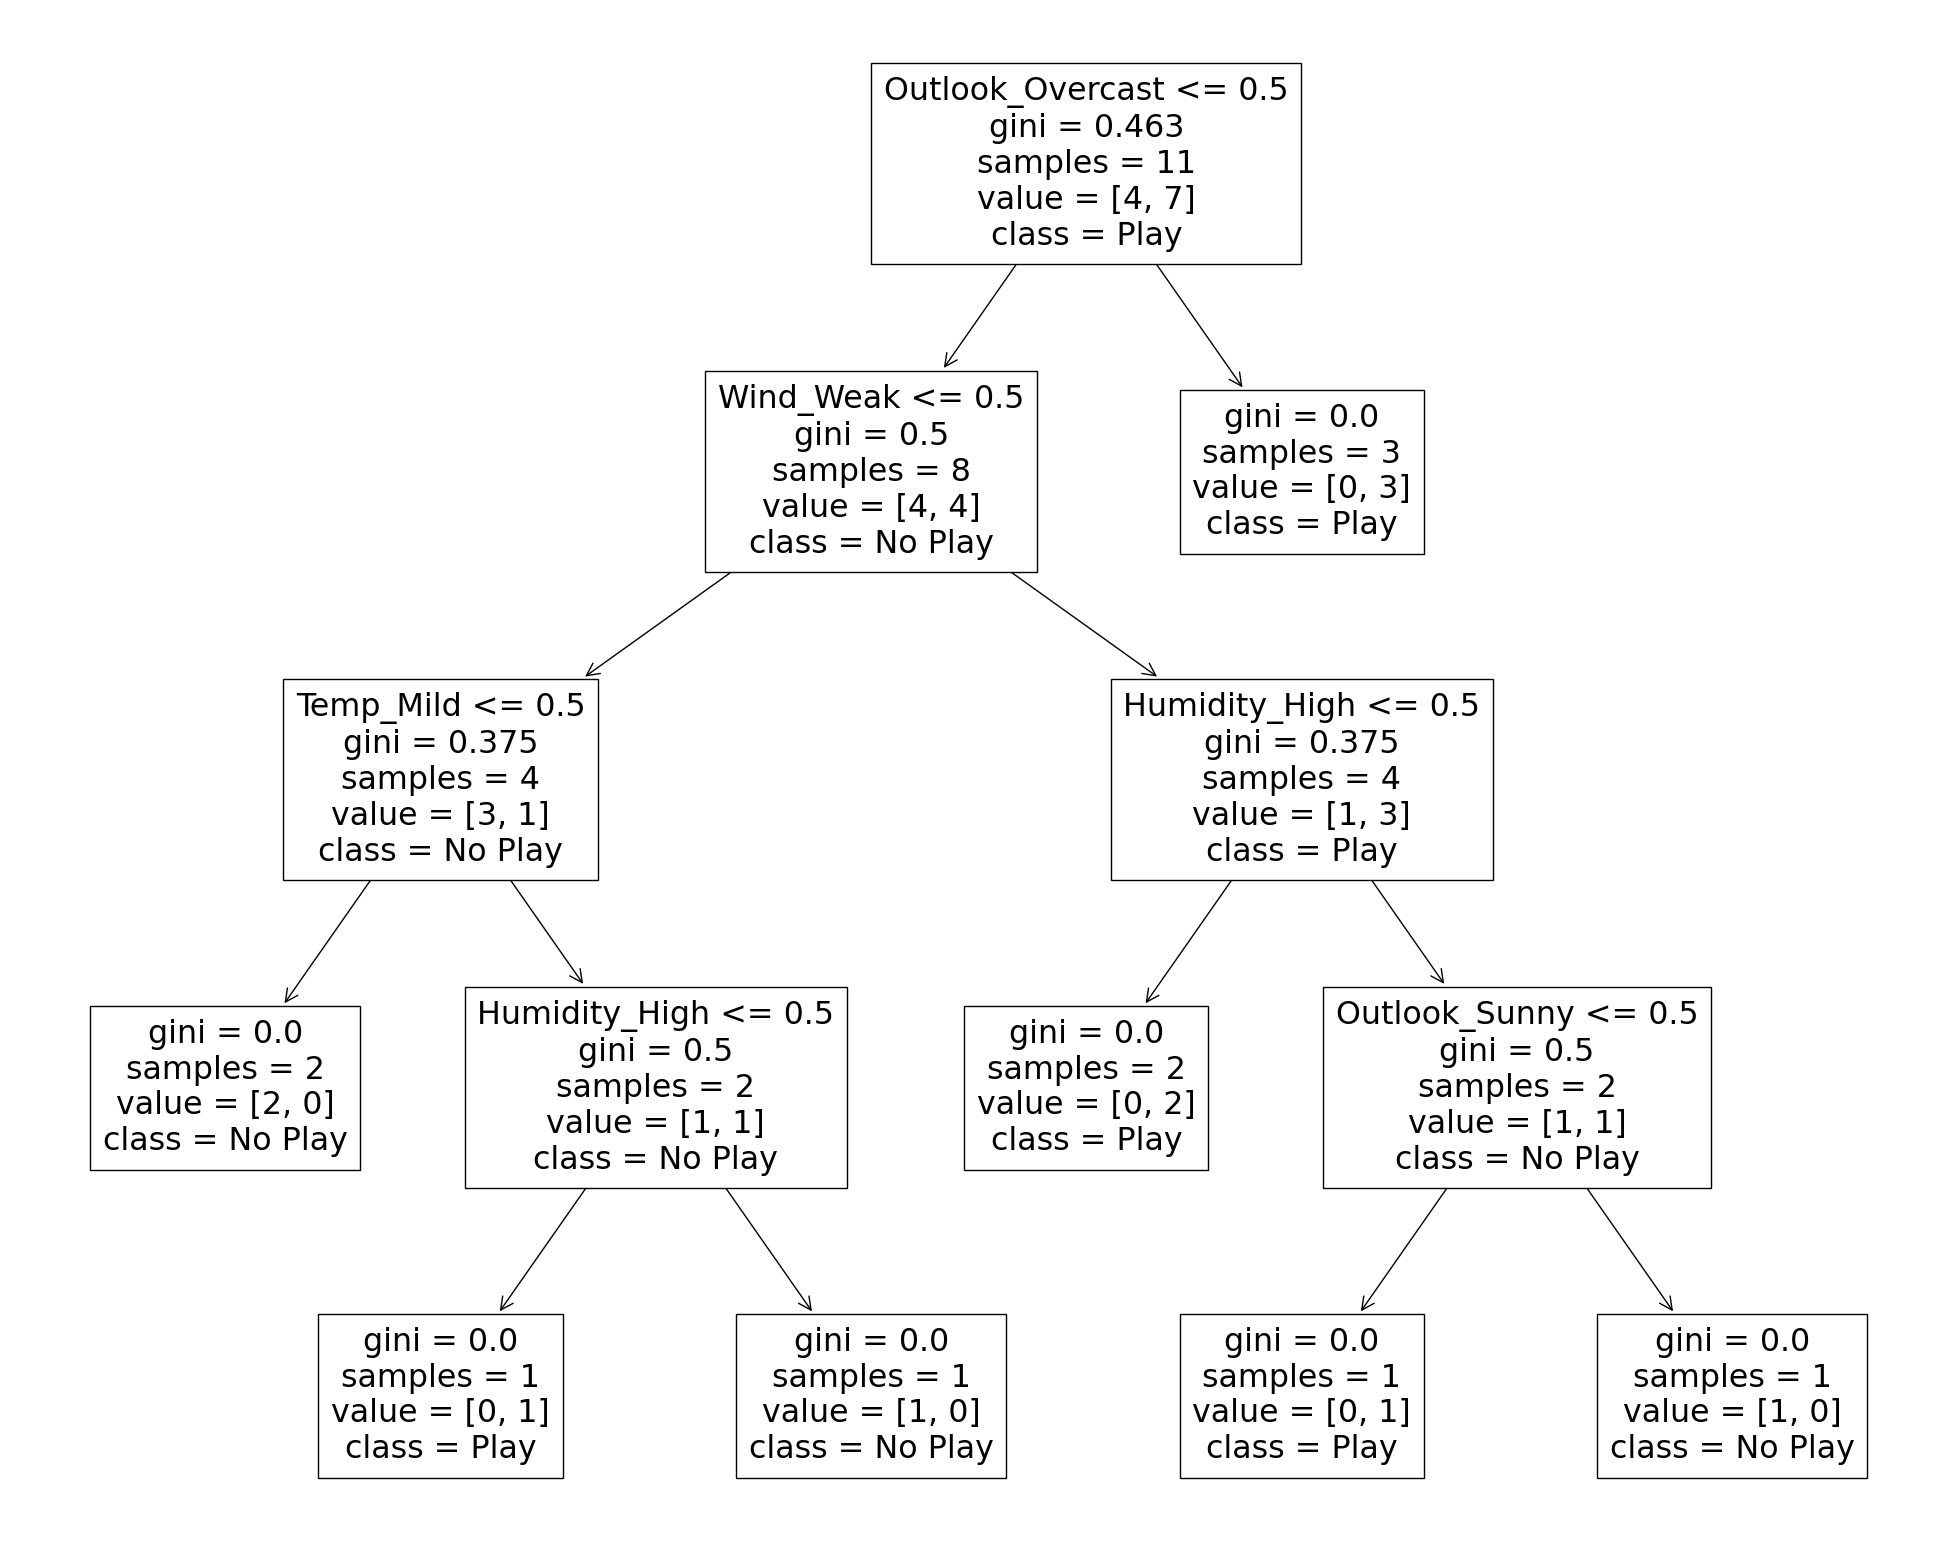

In [81]:
#visualize the tree
plt.figure(figsize=(25,20))
plot_tree(model,feature_names=X.columns,class_names=['No Play','Play'])
plt.show()

In [82]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test,y_test))
print(classification_report(y_test,y_pred))

[[1 0]
 [0 2]]
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [83]:
model = DecisionTreeClassifier(criterion ='entropy', max_depth =3)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

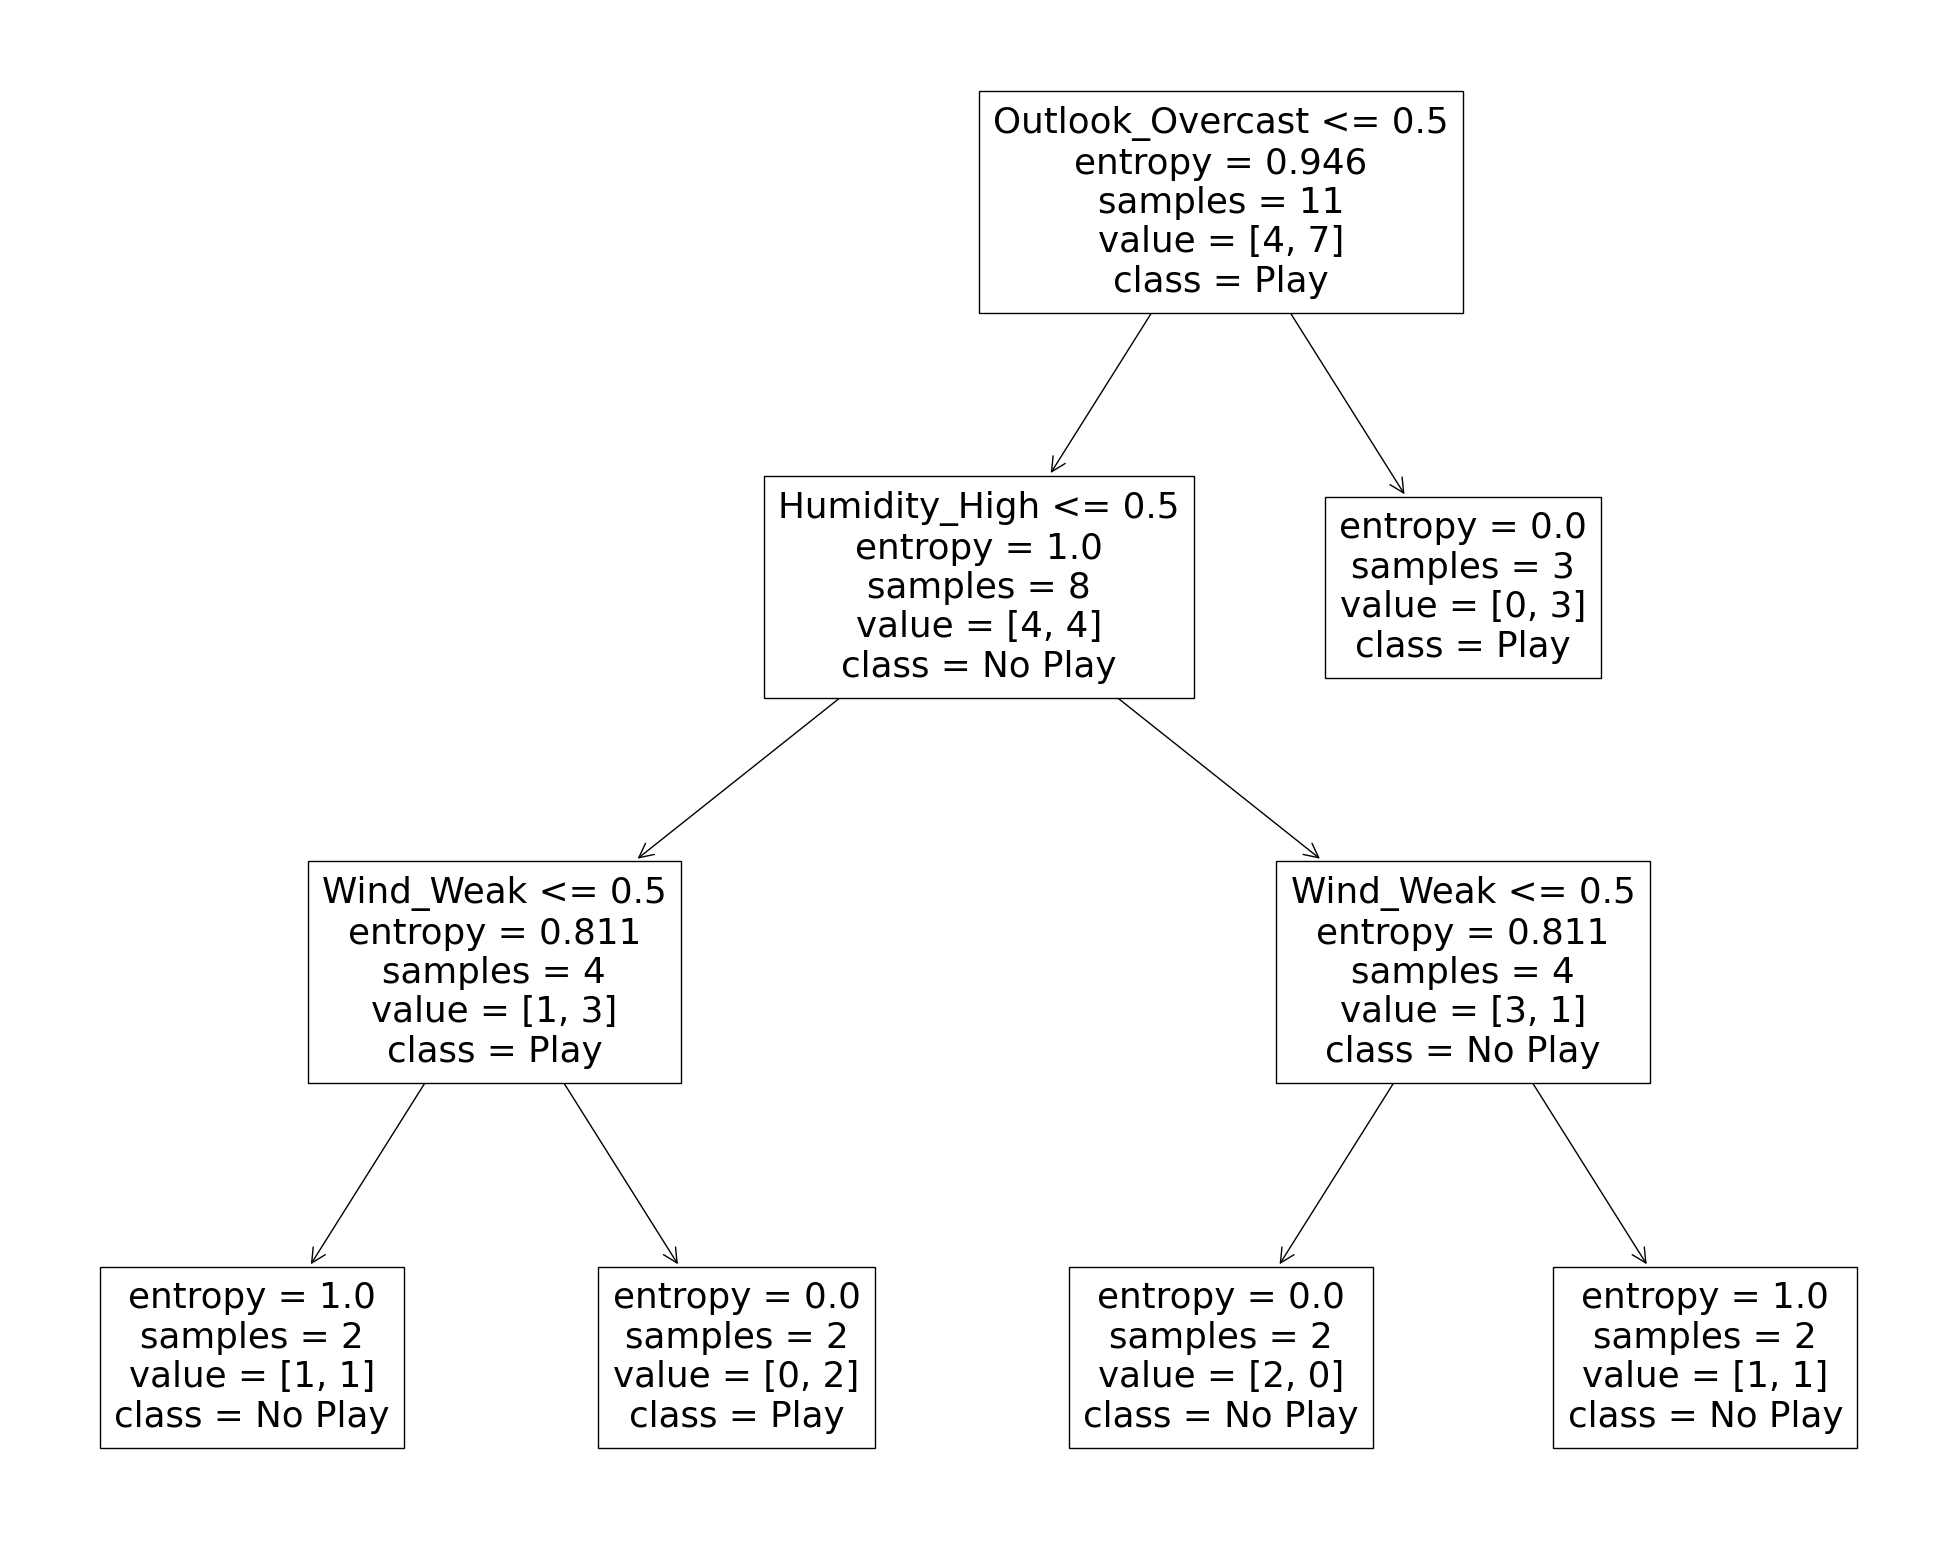

In [84]:
plt.figure(figsize=(25,20))
plot_tree(model,feature_names=X.columns,class_names=['No Play','Play'])
plt.show()

In [85]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test,y_test))
print(classification_report(y_test,y_pred))

[[1 0]
 [0 2]]
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [87]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
model = RandomForestClassifier(n_estimators=10,random_state=42)
model.fit(X_train,y_train)
#make predictions
y_pred=model.predict(X_test)
#print confusion matrix and classification
print(confusion_matrix(y_test,y_test))
print(classification_report(y_test,y_pred))

[[1 0]
 [0 2]]
              precision    recall  f1-score   support

          No       0.50      1.00      0.67         1
         Yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



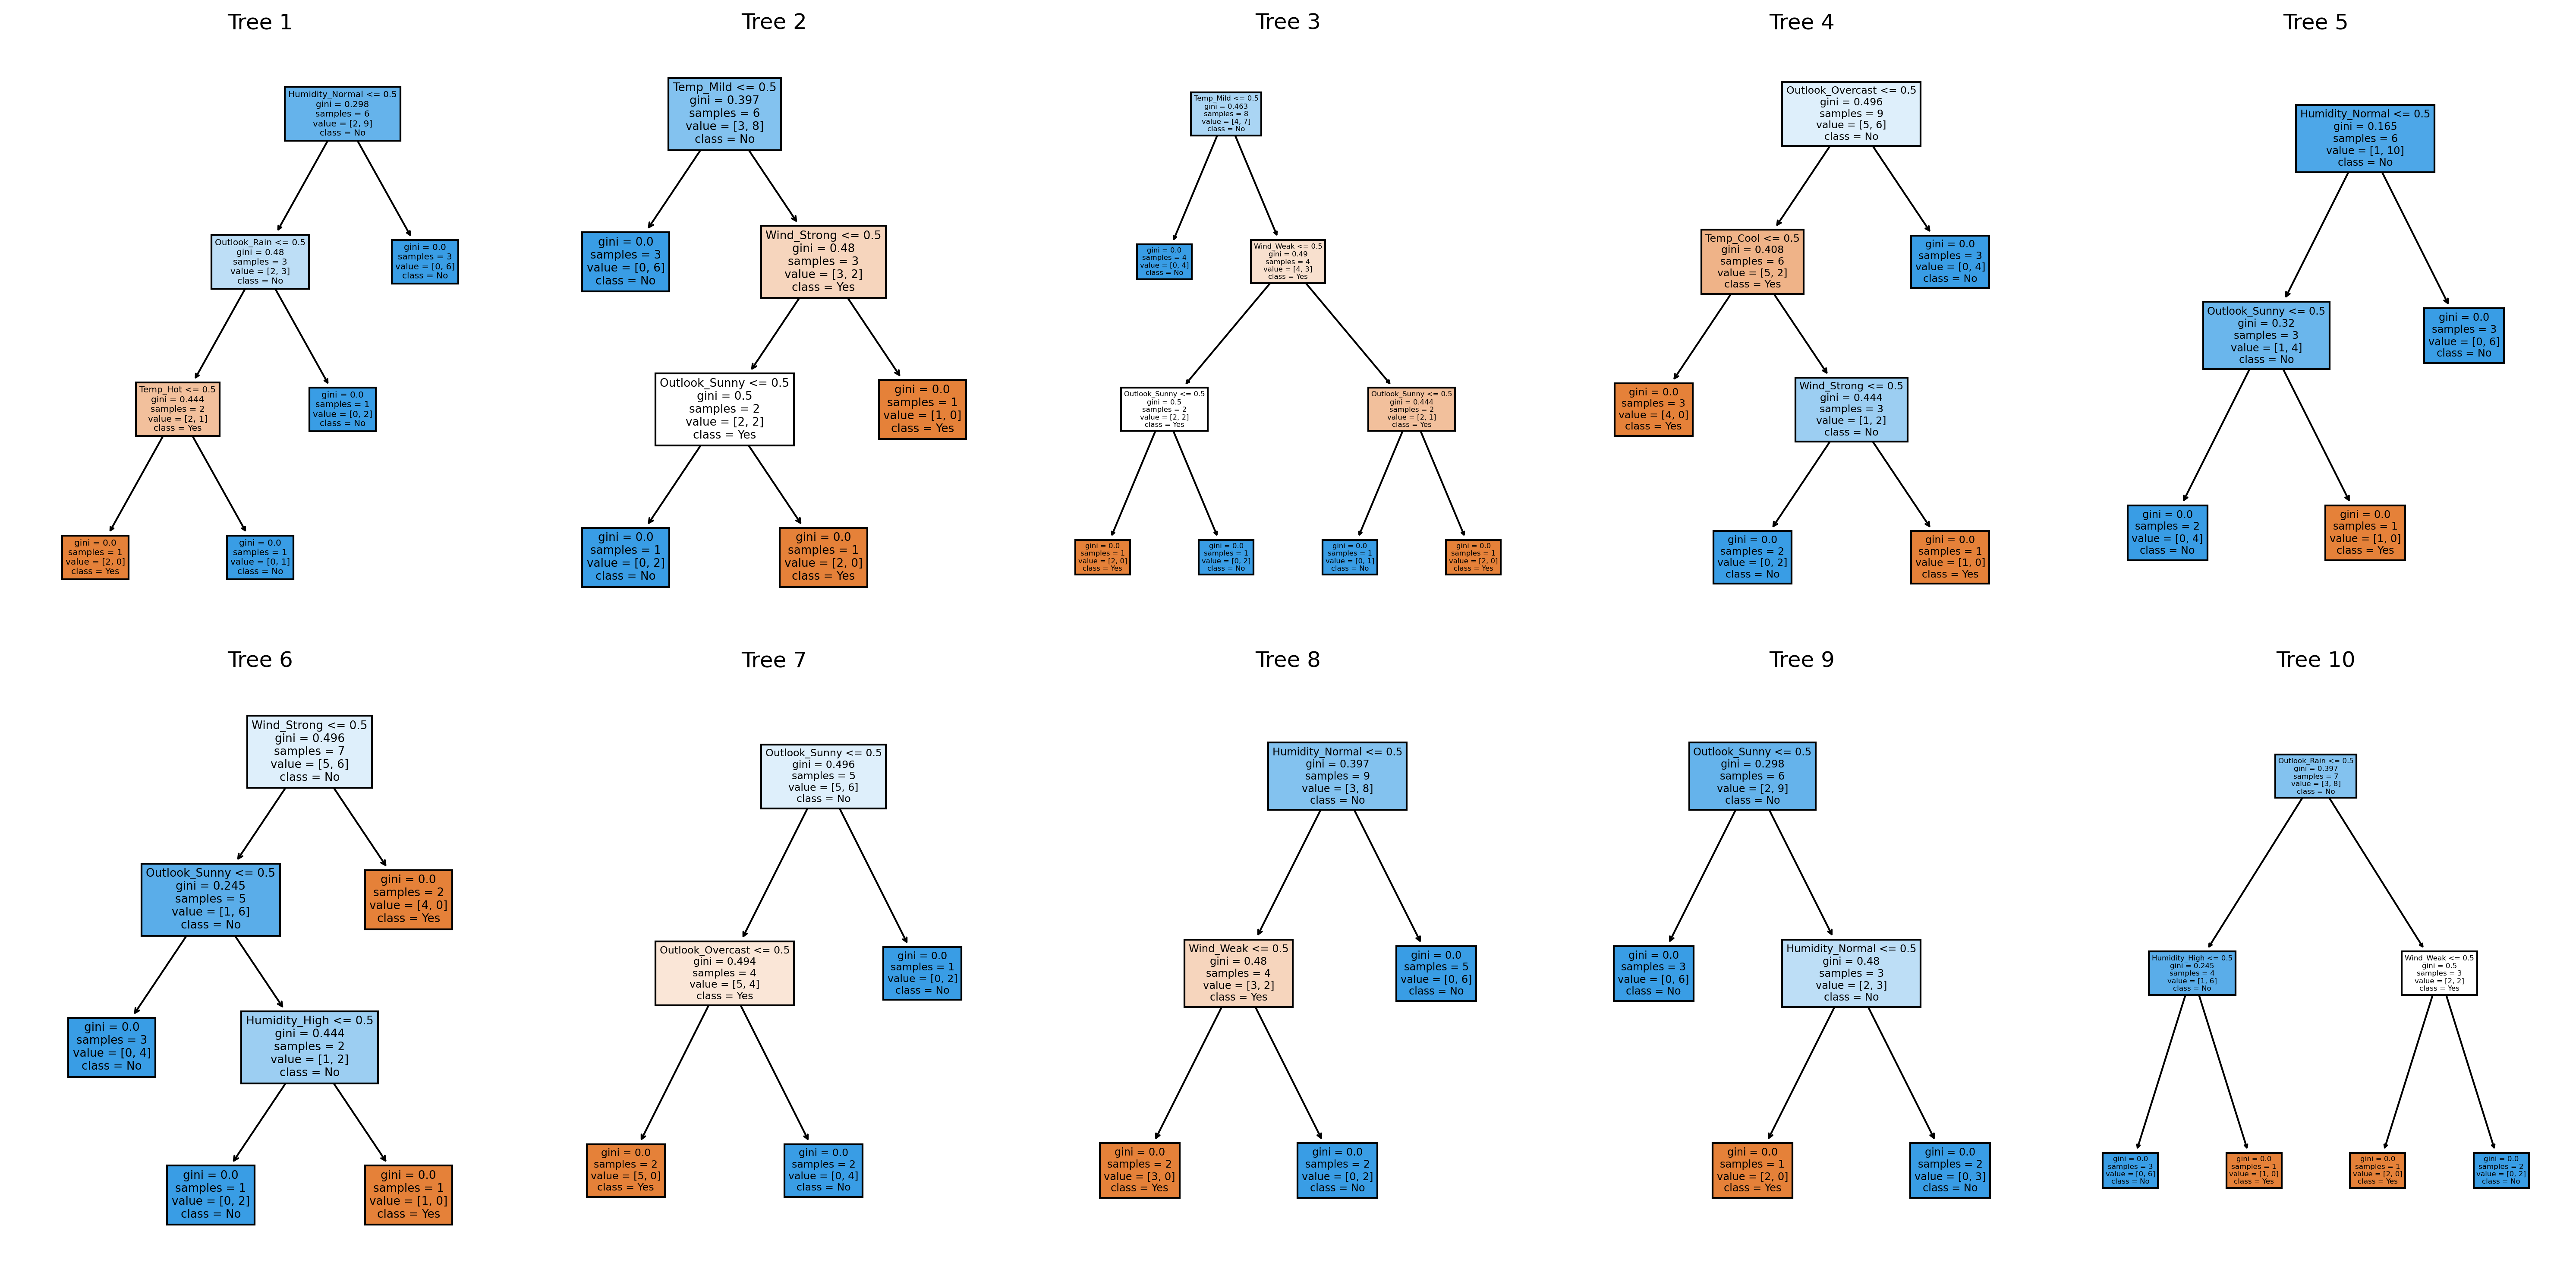

In [95]:
# Set up the figure with appropriate dimensions
num_trees = len(model.estimators_)
cols = 5
rows = (num_trees + cols - 1) // cols

fig,axes = plt.subplots(rows, cols, figsize=(20,10), dpi = 300)
axes = axes.flatten()

# Visualize each decision tree in the Random Forest
for i, tree in enumerate(model.estimators_):
    plot_tree(tree, feature_names= X.columns, class_names=['Yes', 'No'], filled=True, ax=axes[i])
    axes[i].set_title(f"Tree {i+1}")

# Remove unused subplots
for j in range(i+1, num_trees):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()
                